# Validate the `arabin2026` RFI Channel Anomaly Dataset

This notebook validates the exported package rather than recreating it. It
checks the manifest, the split contract and array shapes, then displays random
core examples and challenge spectrograms. Re-run the visual section with a new
seed to inspect different data.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'rfimt').is_dir():
            return candidate
    raise RuntimeError('Open this notebook from a directory inside the rfimt repository.')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from rfimt.student_dataset import (
    STUDENT_CORE_LABELS,
    assert_disjoint_split_groups,
    assign_split_column,
    select_challenge_segments,
    sha256_file,
    stack_complete_segments,
    student_readme,
)


## Load the package

The validation notebook uses the same configuration as the exporter. It never
modifies the package, so it can be used repeatedly before delivery.

In [2]:
CONFIG_PATH = REPO_ROOT / 'configs/student_datasets/b0531_rfi_channel_anomaly_student_v1.json'
with CONFIG_PATH.open(encoding='utf-8') as handle:
    spec = json.load(handle)

core_spec = spec['core']
challenge_spec = spec['challenge']
output_spec = spec['output']
export_root = Path(output_spec['root_directory'])
student_dir = export_root / output_spec['student_directory']
supervisor_dir = export_root / output_spec['supervisor_directory']
if not student_dir.is_dir():
    raise FileNotFoundError(f'Create the student package first: {student_dir}')

core_series = np.load(student_dir / 'core_channel_time_series.npy', mmap_mode='r')
# Preserve literal CSV strings while validating the student-facing BGN label.
core_meta = pd.read_csv(student_dir / 'core_channel_metadata.csv', keep_default_na=False)
challenge_spectra = np.load(student_dir / 'challenge_spectrogram_segments.npy', mmap_mode='r')
challenge_meta = pd.read_csv(student_dir / 'challenge_segment_metadata.csv', keep_default_na=False)
student_manifest = json.loads((student_dir / 'student_manifest.json').read_text(encoding='utf-8'))


## Reconcile files and the split contract

These checks prevent a spreadsheet edit, incomplete transfer or accidental
combination of correlated channels from silently changing what the student is
evaluating.

In [3]:
for filename, expected in student_manifest['files'].items():
    path = student_dir / filename
    if not path.is_file():
        raise FileNotFoundError(f'Manifest file is missing: {filename}')
    if sha256_file(path) != expected['sha256']:
        raise ValueError(f'Manifest hash mismatch: {filename}')

if core_series.ndim != 2 or core_series.shape[1] != core_spec['segment_shape'][1]:
    raise ValueError(f'Unexpected core array shape: {core_series.shape}')
if len(core_series) != len(core_meta):
    raise ValueError('Core array and metadata have different row counts.')
if set(core_meta['label']) != set(STUDENT_CORE_LABELS):
    raise ValueError('Core package contains an unexpected label.')
if not np.array_equal(core_meta['binary_target'].to_numpy(), core_meta['label'].eq('NBRFI').astype(int).to_numpy()):
    raise ValueError('Core binary targets disagree with their labels.')
assert_disjoint_split_groups(core_meta, group_col=core_spec['group_column'])
if not np.isfinite(core_series).all():
    raise ValueError('Core array contains non-finite values.')

expected_shape = (len(challenge_meta), *core_spec['segment_shape'])
if tuple(challenge_spectra.shape) != expected_shape:
    raise ValueError(f'Unexpected challenge array shape: {challenge_spectra.shape}, expected {expected_shape}.')
challenge_overlaps_core = bool(
    set(challenge_meta[core_spec['group_column']]) & set(core_meta[core_spec['group_column']])
)
expected_overlap_permission = not challenge_spec['exclude_core_segments']
if student_manifest['challenge_may_overlap_core_segments'] != expected_overlap_permission:
    raise ValueError('Student manifest and challenge overlap policy disagree.')
if challenge_spec['exclude_core_segments'] and challenge_overlaps_core:
    raise ValueError('Challenge and core share segment identities despite the declared exclusion.')
if not np.isfinite(challenge_spectra).all():
    raise ValueError('Challenge array contains non-finite values.')

print('Manifest, arrays and group split: OK')
print(core_meta.groupby(['split', 'label']).size().rename('channel_rows'))
print('Challenge segments:', len(challenge_meta))


Manifest, arrays and group split: OK
split  label
test   BGN      1000
       NBRFI    1000
train  BGN      8000
       NBRFI    8000
val    BGN      1000
       NBRFI    1000
Name: channel_rows, dtype: int64
Challenge segments: 24


## Optional supervisor-only reconciliation

This cell confirms that held-back challenge labels align with the exported
spectrogram order. Set the flag to `False` before using this notebook as part
of a student-facing package.

In [4]:
VERIFY_SUPERVISOR_ARTIFACTS = True

if VERIFY_SUPERVISOR_ARTIFACTS:
    labels_path = supervisor_dir / 'challenge_channel_labels.csv'
    labels = pd.read_csv(labels_path)
    expected_rows = len(challenge_meta) * core_spec['segment_shape'][0]
    if len(labels) != expected_rows:
        raise ValueError(f'Supervisor labels contain {len(labels)} rows, expected {expected_rows}.')
    if labels['challenge_segment_index'].nunique() != len(challenge_meta):
        raise ValueError('Supervisor labels do not cover every challenge spectrogram.')
    print(labels['source_label'].value_counts().rename('supervisor label rows'))


source_label
NoneWNBRFI    2850
NBRFI          222
Name: supervisor label rows, dtype: int64


## Random visual inspection

Set `VISUAL_SEED` to a different integer and rerun this section to sample new
examples reproducibly. The first figure shows labelled channel time series from
each core split. The second figure shows complete challenge spectrograms with
no hidden labels drawn on top.

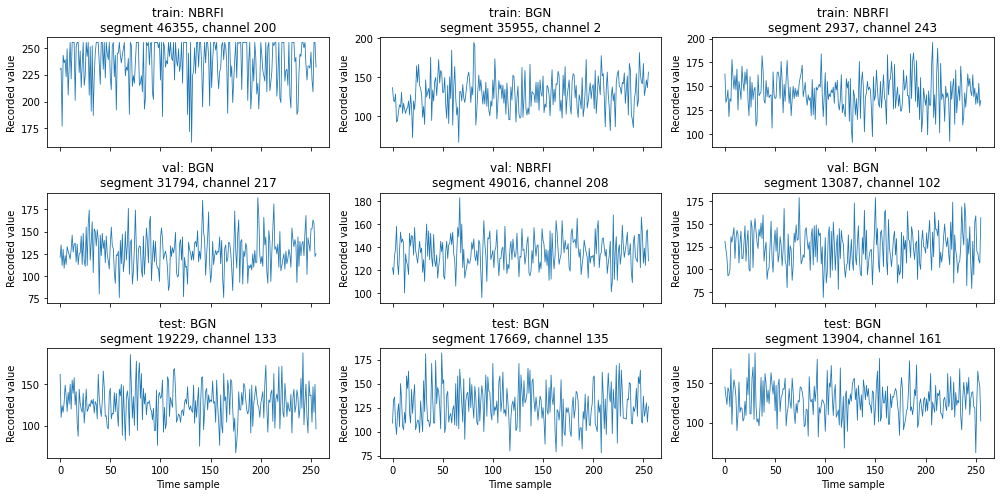

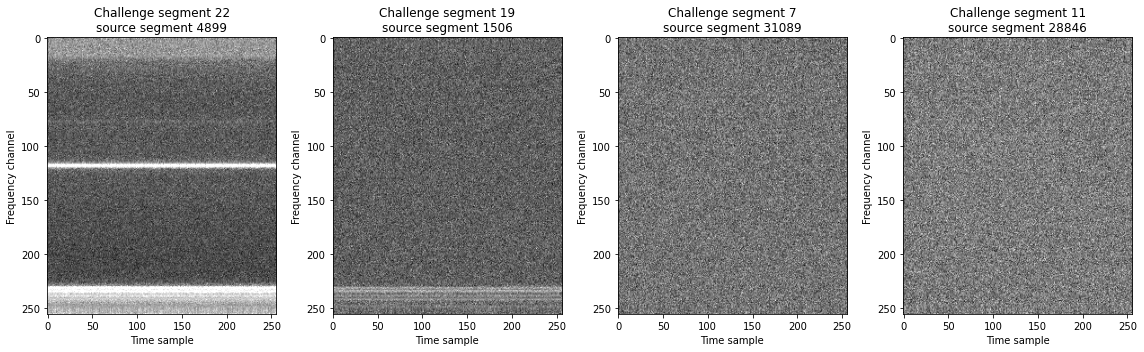

In [7]:
import matplotlib.pyplot as plt

VISUAL_SEED = None
N_CORE_PER_SPLIT = 3
N_CHALLENGE = 4
rng = np.random.default_rng(VISUAL_SEED)

fig, axes = plt.subplots(3, N_CORE_PER_SPLIT, figsize=(14, 7), sharex=True)
for row, split in enumerate(('train', 'val', 'test')):
    candidates = core_meta.index[core_meta['split'].eq(split)].to_numpy()
    chosen = rng.choice(candidates, size=min(N_CORE_PER_SPLIT, len(candidates)), replace=False)
    for column, index in enumerate(chosen):
        record = core_meta.loc[index]
        axes[row, column].plot(core_series[index], linewidth=0.8)
        axes[row, column].set_title(f"{split}: {record['label']}\nsegment {record[core_spec['group_column']]}, channel {record[core_spec['channel_column']]}")
        axes[row, column].set_ylabel('Recorded value')
for axis in axes[-1]:
    axis.set_xlabel('Time sample')
fig.tight_layout()
plt.show()

chosen_challenge = rng.choice(np.arange(len(challenge_meta)), size=min(N_CHALLENGE, len(challenge_meta)), replace=False)
fig, axes = plt.subplots(1, len(chosen_challenge), figsize=(4 * len(chosen_challenge), 5), squeeze=False)
for axis, challenge_index in zip(axes[0], chosen_challenge):
    segment_id = challenge_meta.loc[challenge_index, core_spec['group_column']]
    image = axis.imshow(challenge_spectra[challenge_index], cmap='gray', aspect='auto', origin='upper')
    axis.set_title(f'Challenge segment {challenge_index}\nsource segment {segment_id}')
    axis.set(xlabel='Time sample', ylabel='Frequency channel')
fig.tight_layout()
plt.show()


In [8]:
102.4 * 256

26214.4